In [43]:
import numpy as np
np.random.seed(4)
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from keras.models import Sequential
from keras.layers import Dense, LSTM
import joblib
import warnings
warnings.filterwarnings('ignore')

def graficar_predicciones(real, prediccion, titulo='Predicción de Demanda'):
    plt.figure(figsize=(14, 5))
    plt.plot(real[:len(prediccion)], color='red', label='Demanda real')
    plt.plot(prediccion, color='blue', label='Predicción LSTM')
    plt.title(titulo)
    plt.xlabel('Tiempo')
    plt.ylabel('Tickets vendidos')
    plt.legend()
    plt.tight_layout()
    plt.show()

2

In [44]:
data = pd.read_csv('../data/raw/train_revised.csv')
data['travel_date'] = pd.to_datetime(data['travel_date'], dayfirst=True)

kisii_diario = (
    data[data['travel_from'] == 'Kisii']
    .groupby('travel_date')
    .size()
    .reset_index(name='tickets')
    .sort_values('travel_date')
)

# Solo usamos desde donde hay datos reales (descartamos ceros iniciales)
kisii_diario = kisii_diario[kisii_diario['tickets'] > 0].reset_index(drop=True)

# Crear serie continua SIN días vacíos iniciales
idx = pd.date_range(kisii_diario['travel_date'].min(), 
                    kisii_diario['travel_date'].max(), freq='D')
kisii_diario = kisii_diario.set_index('travel_date').reindex(idx, fill_value=0)
kisii_diario.index.name = 'fecha'
kisii_diario = kisii_diario.reset_index()

print("Total días:", len(kisii_diario))
print("Rango:", kisii_diario['fecha'].min().date(), "→", kisii_diario['fecha'].max().date())
print("Días con tickets > 0:", (kisii_diario['tickets'] > 0).sum())

Total días: 158
Rango: 2017-11-14 → 2018-04-20
Días con tickets > 0: 145


3

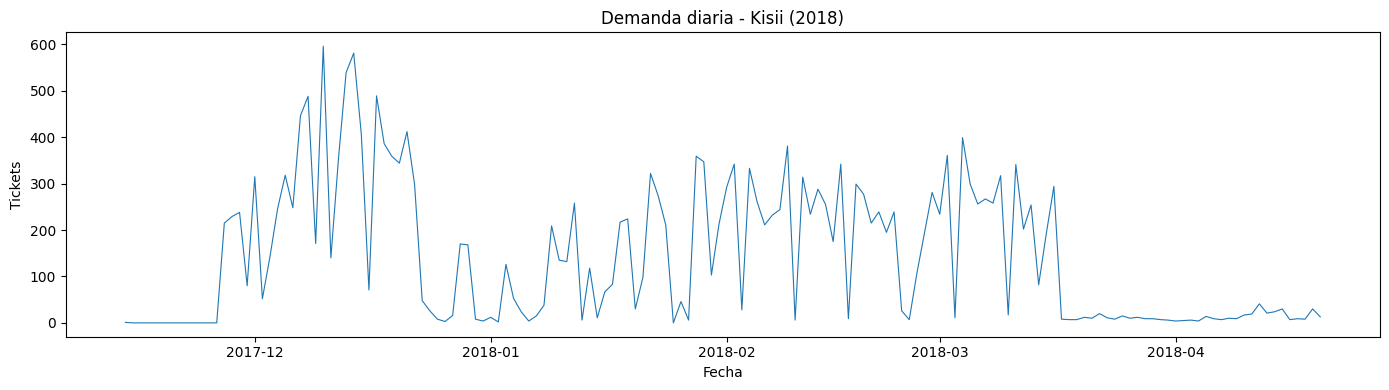

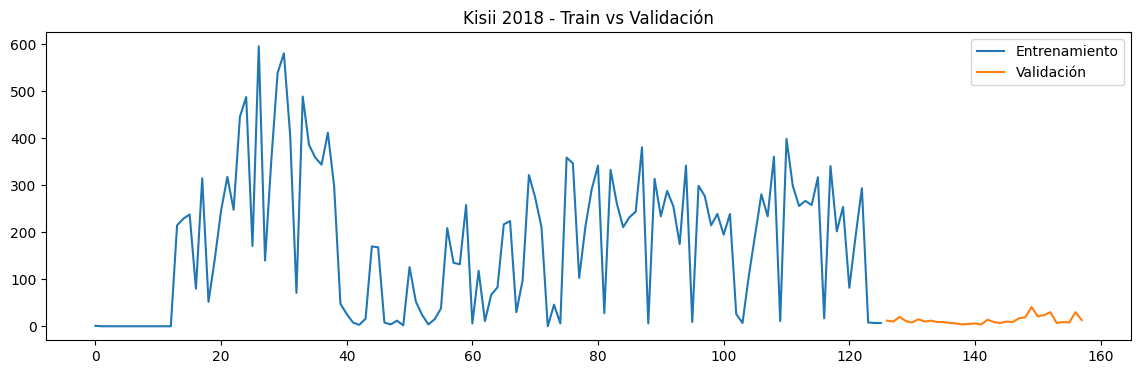

Train: 126 días
Validación: 32 días


In [45]:
plt.figure(figsize=(14, 4))
plt.plot(kisii_diario['fecha'], kisii_diario['tickets'], linewidth=0.8)
plt.title('Demanda diaria - Kisii (2018)')
plt.xlabel('Fecha')
plt.ylabel('Tickets')
plt.tight_layout()
plt.show()

# 80% train, 20% validación
n = len(kisii_diario)
corte = int(n * 0.8)

set_entrenamiento = kisii_diario.iloc[:corte][['tickets']]
set_validacion    = kisii_diario.iloc[corte:][['tickets']]

set_entrenamiento['tickets'].plot(legend=True, label='Entrenamiento', figsize=(14,4))
set_validacion['tickets'].plot(legend=True, label='Validación')
plt.legend()
plt.title('Kisii 2018 - Train vs Validación')
plt.show()

print(f"Train: {len(set_entrenamiento)} días")
print(f"Validación: {len(set_validacion)} días")

4

In [46]:
sc = MinMaxScaler(feature_range=(0, 1))
set_entrenamiento_escalado = sc.fit_transform(set_entrenamiento)

joblib.dump(sc, '../models/scaler_lstm.pkl')
print("✓ Scaler guardado")

✓ Scaler guardado


5

In [47]:
time_step = 7  # 1 semana de contexto
X_train, Y_train = [], []
m = len(set_entrenamiento_escalado)

for i in range(time_step, m):
    X_train.append(set_entrenamiento_escalado[i-time_step:i, 0])
    Y_train.append(set_entrenamiento_escalado[i, 0])

X_train, Y_train = np.array(X_train), np.array(Y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

print(f"X_train: {X_train.shape}")
print(f"Y_train: {Y_train.shape}")

X_train: (119, 7, 1)
Y_train: (119,)


6

In [48]:
dim_entrada = (X_train.shape[1], 1)
na = 50

modelo = Sequential()
modelo.add(LSTM(units=na, input_shape=dim_entrada))
modelo.add(Dense(units=1))
modelo.compile(optimizer='rmsprop', loss='mse')

history = modelo.fit(X_train, Y_train, epochs=100, batch_size=8, verbose=1)
print("✓ Entrenado")

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1049   
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0526 
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0508 
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0480 
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0497 
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0464 
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0488 
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0502 
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0483 
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0476 
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0486 
Epoch 12/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0486 
Epoch 13/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0487 
Epoch 14/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0472 
Epoch 15/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - l

7

In [49]:
x_test = set_validacion.values
x_test = sc.transform(x_test)

X_test = []
for i in range(time_step, len(x_test)):
    X_test.append(x_test[i-time_step:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

prediccion = modelo.predict(X_test)
prediccion = sc.inverse_transform(prediccion)

print(f"Predicciones: {len(prediccion)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
Predicciones: 25


8

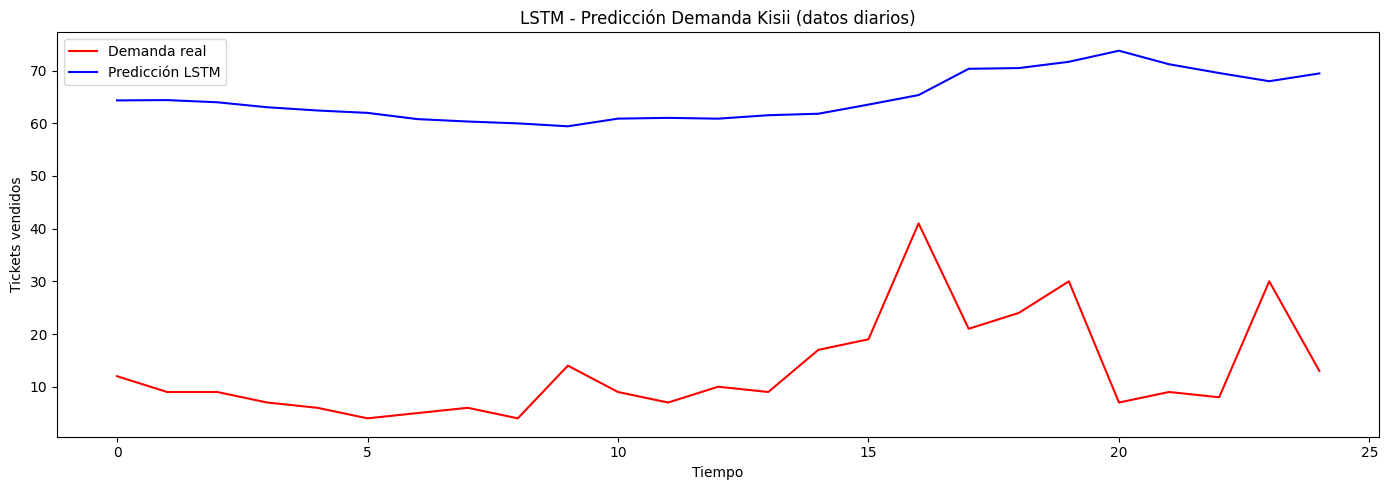

<Figure size 640x480 with 0 Axes>

In [50]:
graficar_predicciones(
    set_validacion.values[time_step:],
    prediccion,
    titulo='LSTM - Predicción Demanda Kisii (datos diarios)'
)
plt.savefig('../reports/figures/lstm_prediccion.png', dpi=150, bbox_inches='tight')

9

In [51]:
real = set_validacion.values[time_step:].flatten()
pred = prediccion.flatten()

mse  = mean_squared_error(real, pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(real, pred)
r2   = r2_score(real, pred)

print("=== MÉTRICAS LSTM (datos diarios) ===")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

=== MÉTRICAS LSTM (datos diarios) ===
MSE:  2735.4583
RMSE: 52.3016
MAE:  51.6016
R²:   -30.8669


10

In [52]:
modelo.save('../models/modelo_lstm.h5')

import json
metricas = {'MSE': round(float(mse),4), 'RMSE': round(float(rmse),4),
            'MAE': round(float(mae),4), 'R2': round(float(r2),4)}
with open('../reports/metricas_lstm.json', 'w') as f:
    json.dump(metricas, f, indent=2)
print("✓ Todo guardado")
print(metricas)

✓ Todo guardado
{'MSE': 2735.4583, 'RMSE': 52.3016, 'MAE': 51.6016, 'R2': -30.8669}


11

In [53]:
# Celda 2 - Solo usar datos de 2018 donde la serie es más estable
data = pd.read_csv('../data/raw/train_revised.csv')
data['travel_date'] = pd.to_datetime(data['travel_date'], dayfirst=True)

kisii_diario = (
    data[data['travel_from'] == 'Kisii']
    .groupby('travel_date')
    .size()
    .reset_index(name='tickets')
    .sort_values('travel_date')
)

# Filtrar solo 2018 (período estable)
kisii_diario = kisii_diario[kisii_diario['travel_date'] >= '2018-01-01'].reset_index(drop=True)

# Serie continua
idx = pd.date_range(kisii_diario['travel_date'].min(), 
                    kisii_diario['travel_date'].max(), freq='D')
kisii_diario = kisii_diario.set_index('travel_date').reindex(idx, fill_value=0)
kisii_diario.index.name = 'fecha'
kisii_diario = kisii_diario.reset_index()

print("Total días 2018:", len(kisii_diario))
print(kisii_diario.head())

Total días 2018: 110
       fecha  tickets
0 2018-01-01       12
1 2018-01-02        2
2 2018-01-03      126
3 2018-01-04       53
4 2018-01-05       24
